In [4]:
import tpqoa

In [5]:
api = tpqoa.tpqoa('pyalgo_hedging.cfg')

In [6]:
api.get_instruments()[:15]

[('AUD/CAD', 'AUD_CAD'),
 ('AUD/CHF', 'AUD_CHF'),
 ('AUD/HKD', 'AUD_HKD'),
 ('AUD/JPY', 'AUD_JPY'),
 ('AUD/NZD', 'AUD_NZD'),
 ('AUD/SGD', 'AUD_SGD'),
 ('AUD/USD', 'AUD_USD'),
 ('CAD/CHF', 'CAD_CHF'),
 ('CAD/HKD', 'CAD_HKD'),
 ('CAD/JPY', 'CAD_JPY'),
 ('CAD/SGD', 'CAD_SGD'),
 ('CHF/HKD', 'CHF_HKD'),
 ('CHF/JPY', 'CHF_JPY'),
 ('CHF/ZAR', 'CHF_ZAR'),
 ('EUR/AUD', 'EUR_AUD')]

In [7]:
help(api.get_history)

Help on method get_history in module tpqoa.tpqoa:

get_history(instrument, start, end, granularity, price, localize=True) method of tpqoa.tpqoa.tpqoa instance
    Retrieves historical data for instrument.

    Parameters
    instrument: string
        valid instrument name
    start, end: datetime, str
        Python datetime or string objects for start and end
    granularity: string
        a string like 'S5', 'M1' or 'D'
    price: string
        one of 'A' (ask), 'B' (bid) or 'M' (middle)

    Returns
    data: pd.DataFrame
        pandas DataFrame object with data



In [8]:
instrument = 'EUR_USD'
start = '2020-08-10'
end = '2020-08-13'
granularity = 'M1'
price = 'M'

In [9]:
data = api.get_history(instrument, start, end, granularity, price)

In [10]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 4221 entries, 2020-08-10 00:00:00 to 2020-08-13 00:00:00
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   o         4221 non-null   float64
 1   h         4221 non-null   float64
 2   l         4221 non-null   float64
 3   c         4221 non-null   float64
 4   volume    4221 non-null   int64  
 5   complete  4221 non-null   bool   
dtypes: bool(1), float64(4), int64(1)
memory usage: 202.0 KB


In [11]:
data[['c', 'volume']].head()

,c,volume
time,,
2020-08-10 00:00:00,1.17822,18
2020-08-10 00:01:00,1.17836,32
2020-08-10 00:02:00,1.17828,25
2020-08-10 00:03:00,1.17834,13
2020-08-10 00:04:00,1.17847,43


In [12]:
import numpy as np
data['returns'] = np.log(data['c'] / data['c'].shift(1))
cols = []
for momentum in [15, 30, 60, 120]:
    col = 'position_{}'.format(momentum)
    data[col]  = np.sign(data['returns'].rolling(momentum).mean())
    cols.append(col)


In [13]:
data.tail()

,o,h,l,c,volume,complete,returns,position_15,position_30,position_60,position_120
time,,,,,,,,,,,
2020-08-12 23:56:00,1.17946,1.17946,1.17942,1.17943,25,True,-0.000034,1.0,1.0,1.0,1.0
2020-08-12 23:57:00,1.17942,1.17943,1.17932,1.17932,19,True,-0.000093,-1.0,1.0,1.0,1.0
2020-08-12 23:58:00,1.17933,1.17941,1.17933,1.17938,27,True,0.000051,-1.0,1.0,1.0,1.0
2020-08-12 23:59:00,1.17940,1.17942,1.17938,1.17942,7,True,0.000034,-1.0,1.0,1.0,1.0
2020-08-13 00:00:00,1.17940,1.17968,1.17939,1.17958,75,True,0.000136,1.0,1.0,1.0,1.0


In [14]:
from pylab import plt
plt.style.use('seaborn-v0_8')
import matplotlib as mpl
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['font.family'] = 'serif'


<Axes: xlabel='time'>

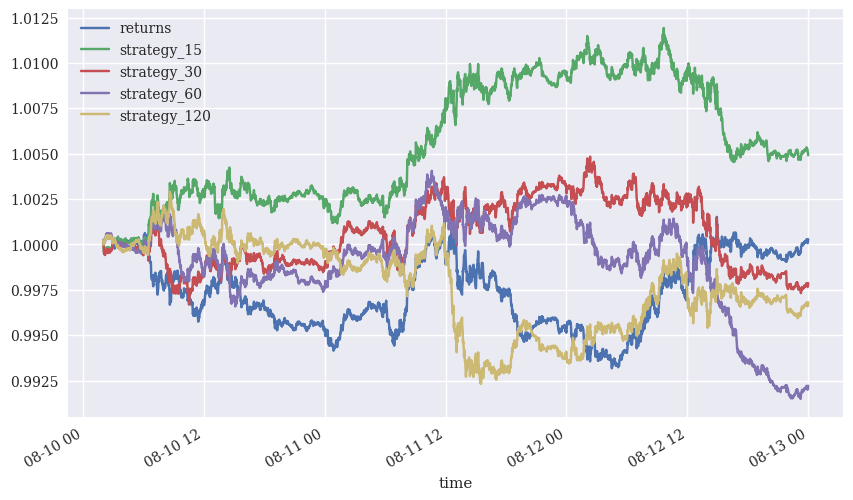

In [15]:
strats = ['returns']
for col  in cols:
    strat = 'strategy_{}'.format(col.split('_')[1])
    data[strat] = data[col].shift(1) * data['returns']
    strats.append(strat)
data[strats].dropna().cumsum(
    ).apply(np.exp).plot(figsize=(10,6))


<Axes: xlabel='time'>

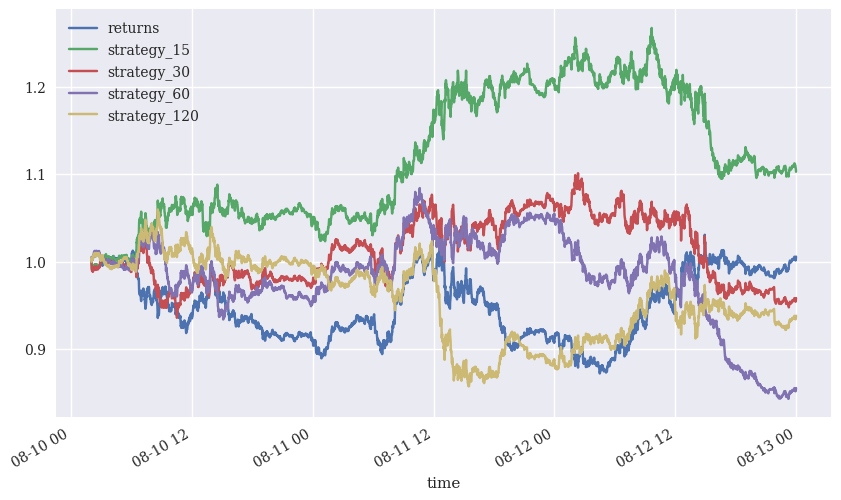

In [16]:
data[strats].dropna().cumsum().apply(lambda x: x * 20).apply(np.exp).plot(figsize=(10,6))

In [17]:
instrument = 'EUR_USD'  
api.stream_data(instrument, stop=10)

2026-07-07T03:38:26.308347035Z 1.14388 1.14393
2026-07-07T03:38:27.909504012Z 1.14388 1.14393
2026-07-07T03:38:30.309742531Z 1.14388 1.14393
2026-07-07T03:38:39.860464715Z 1.14388 1.14393
2026-07-07T03:38:40.565772405Z 1.14388 1.14393
2026-07-07T03:38:47.384539691Z 1.14388 1.14393
2026-07-07T03:38:47.602970944Z 1.14388 1.14393
2026-07-07T03:38:48.416709044Z 1.14387 1.14392
2026-07-07T03:38:49.284026850Z 1.14386 1.14391
2026-07-07T03:38:50.206771081Z 1.14385 1.1439


In [18]:
help(api.create_order)


Help on method create_order in module tpqoa.tpqoa:

create_order(
    instrument,
    units,
    price=None,
    sl_distance=None,
    tsl_distance=None,
    tp_price=None,
    comment=None,
    touch=False,
    suppress=False,
    ret=False
) method of tpqoa.tpqoa.tpqoa instance
    Places order with Oanda.

    Parameters
    instrument: string
        valid instrument name
    units: int
        number of units of instrument to be bought
        (positive int, eg 'units=50')
        or to be sold (negative int, eg 'units=-100')
    price: float
        limit order price, touch order price
    sl_distance: float
        stop loss distance price, mandatory eg in Germany
    tsl_distance: float
        trailing stop loss distance
    tp_price: float
        take profit price to be used for the trade
    comment: str
        string
    touch: boolean
        market_if_touched order (requires price to be set)
    suppress: boolean
        whether to suppress print out
    ret: boolean
  

In [19]:
# api.create_order(instrument, 1000)

In [20]:
# api.create_order(instrument, -1500)

In [21]:
# api.create_order(instrument,500)

In [22]:
# api.create_order(instrument,1000)

In [23]:
# api.create_order(instrument,-1000)

In [45]:
import MomentumTrader as MT
mt = MT.MomentumTrader('/workspace/src/pyalgo_hedging.cfg',
                       instrument=instrument,
                       bar_length='10s',
                       momentum=6,
                       units=10000)
mt.stream_data(mt.instrument, stop=500)

1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 min before if = 8
--- BEFORE decision ---
self.position = 0
signal (data['position'].iloc[-2]) = 1.0
pattern A


 {'id': '700', 'time': '2026-07-07T05:46:10.312772210Z', 'userID': 39660133, 'accountID': '101-009-39660133-003', 'batchID': '699', 'requestID': '115566526107841249', 'type': 'ORDER_FILL', 'orderID': '699', 'instrument': 'EUR_USD', 'units': '10000.0', 'gainQuoteHomeConversionFactor': '161.530292', 'lossQuoteHomeConversionFactor': '162.177708', 'price': 1.14296, 'fullVWAP': 1.14296, 'fullPrice': {'type': 'PRICE', 'bids': [{'price': 1.14291, 'liquidity': '250000'}], 'asks': [{'price': 1.14296, 'liquidity': '250000'}], 'closeoutBid': 1.14285, 'closeoutAsk': 1.14302}, 'reason': 'MARKET_ORDER', 'pl': '0.0', 'financing': '0.0', 'commission': '0.0', 'guaranteedExecutionFee': '0.0', 'accountBalance': '1491668.2755', 'tradeOpened': {'tradeID': '700

KeyboardInterrupt: 

In [26]:
print(-mt.position, mt.units)

1 10000


In [27]:
oo = mt.create_order(instrument, units=-mt.position * mt.units, ret=True, suppress=True)

In [52]:
api.get_account_summary()

{'id': '101-009-39660133-003',
 'alias': 'Trial_account',
 'currency': 'JPY',
 'balance': '1491392.6041',
 'createdByUserID': 39660133,
 'createdTime': '2026-06-26T03:50:27.562348350Z',
 'guaranteedStopLossOrderMode': 'DISABLED',
 'pl': '-28718.5518',
 'resettablePL': '-28718.5518',
 'resettablePLTime': '0',
 'financing': '-48.8441',
 'commission': '0.0',
 'guaranteedExecutionFees': '0.0',
 'marginRate': '0.02',
 'openTradeCount': 0,
 'openPositionCount': 0,
 'pendingOrderCount': 0,
 'hedgingEnabled': True,
 'unrealizedPL': '0.0',
 'NAV': '1491392.6041',
 'marginUsed': '0.0',
 'marginAvailable': '1491392.6041',
 'positionValue': '0.0',
 'marginCloseoutUnrealizedPL': '0.0',
 'marginCloseoutNAV': '1491392.6041',
 'marginCloseoutMarginUsed': '0.0',
 'marginCloseoutPercent': '0.0',
 'marginCloseoutPositionValue': '0.0',
 'withdrawalLimit': '1491392.6041',
 'lastTransactionID': '706'}

In [54]:
api.get_transactions(tid=703)

[{'id': '704',
  'time': '2026-07-07T05:49:13.561434740Z',
  'userID': 39660133,
  'accountID': '101-009-39660133-003',
  'batchID': '703',
  'requestID': '97552128366946355',
  'type': 'ORDER_FILL',
  'orderID': '703',
  'instrument': 'EUR_USD',
  'units': '20000.0',
  'gainQuoteHomeConversionFactor': '161.512328',
  'lossQuoteHomeConversionFactor': '162.159672',
  'price': 1.14292,
  'fullVWAP': 1.14292,
  'fullPrice': {'type': 'PRICE',
   'bids': [{'price': 1.14287, 'liquidity': '250000'}],
   'asks': [{'price': 1.14292, 'liquidity': '250000'}],
   'closeoutBid': 1.14282,
   'closeoutAsk': 1.14297},
  'reason': 'MARKET_ORDER_TRADE_CLOSE',
  'pl': '-129.7277',
  'financing': '0.0',
  'commission': '0.0',
  'guaranteedExecutionFee': '0.0',
  'accountBalance': '1491538.5478',
  'tradesClosed': [{'tradeID': '702',
    'units': '20000.0',
    'price': 1.14292,
    'realizedPL': '-129.7277',
    'financing': '0.0',
    'guaranteedExecutionFee': '0.0',
    'halfSpreadCost': '80.918'}],
  '